# Morphology in Binary Images

## Erosion, Dilation, Opening, and Closing


In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## Basic Morphology Operations

First, let's apply simple erosion, dilation, opening, and closing on a small synthetic binary image.

Binary Image:
[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 1 1 0 1 1 1 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


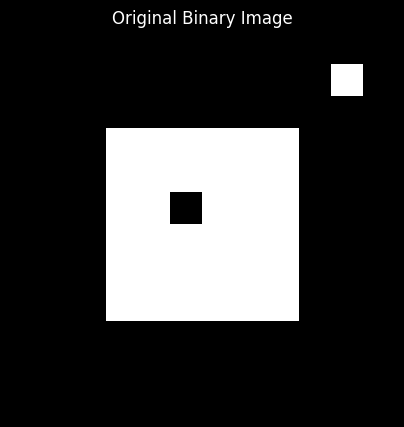

In [11]:
img = np.zeros((12, 12), dtype=np.uint8)
img[3:9, 3:9] = 1
img[5, 5] = 0
img[1, 10] = 1

print("Binary Image:")
print(img)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.title("Original Binary Image")
plt.axis("off")
plt.show()

In [12]:
kernel = np.ones((3, 3), dtype=np.uint8)
print("3x3 Kernel:")
print(kernel)

3x3 Kernel:
[[1 1 1]
 [1 1 1]
 [1 1 1]]


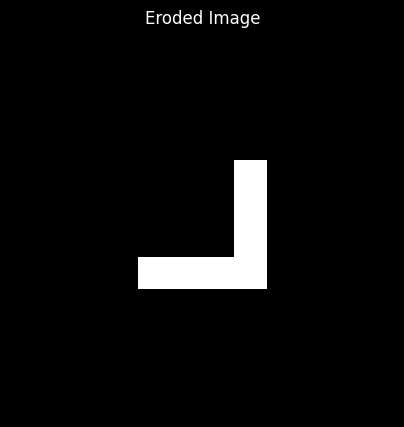

In [13]:
eroded = cv2.erode(img, kernel, iterations=1)

plt.figure(figsize=(5, 5))
plt.imshow(eroded, cmap='gray', vmin=0, vmax=1)
plt.title("Eroded Image")
plt.axis("off")
plt.show()

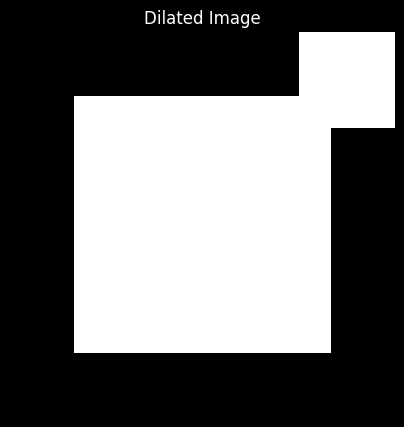

In [14]:
dilated = cv2.dilate(img, kernel, iterations=1)

plt.figure(figsize=(5, 5))
plt.imshow(dilated, cmap='gray', vmin=0, vmax=1)
plt.title("Dilated Image")
plt.axis("off")
plt.show()

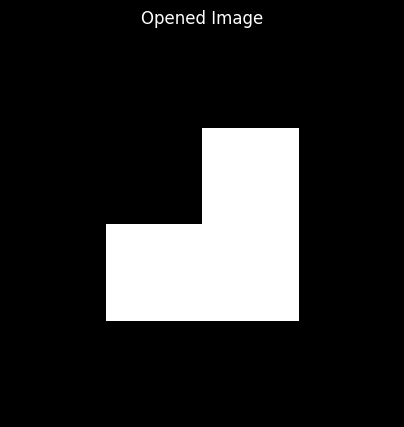

In [15]:
opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(5, 5))
plt.imshow(opened, cmap='gray', vmin=0, vmax=1)
plt.title("Opened Image")
plt.axis("off")
plt.show()

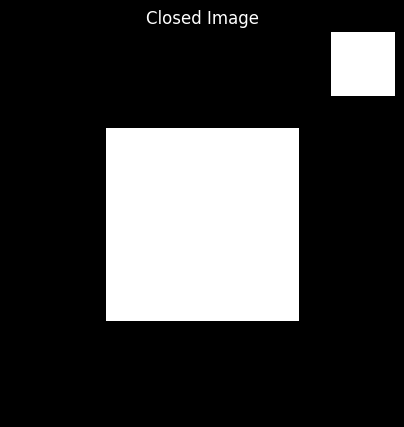

In [16]:
closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(5, 5))
plt.imshow(closed, cmap='gray', vmin=0, vmax=1)
plt.title("Closed Image")
plt.axis("off")
plt.show()

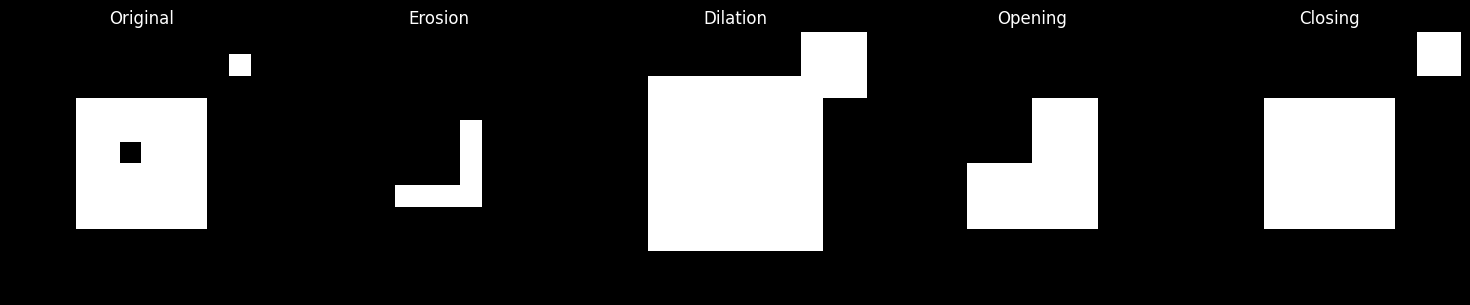

In [17]:
images = [img, eroded, dilated, opened, closed]
titles = ["Original", "Erosion", "Dilation", "Opening", "Closing"]

plt.figure(figsize=(15, 3))
for i in range(len(images)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=1)
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

---

## 21. Extra

Using real black-and-white images (finger.png and text.png).

- apply all four operations
- test at least two different kernels
- write a short comparison report with figures

### 1. Image Description

We use two real images:
- **finger.png**: Fingerprint image with ridges and valleys
- **text.png**: Text document with characters and noise

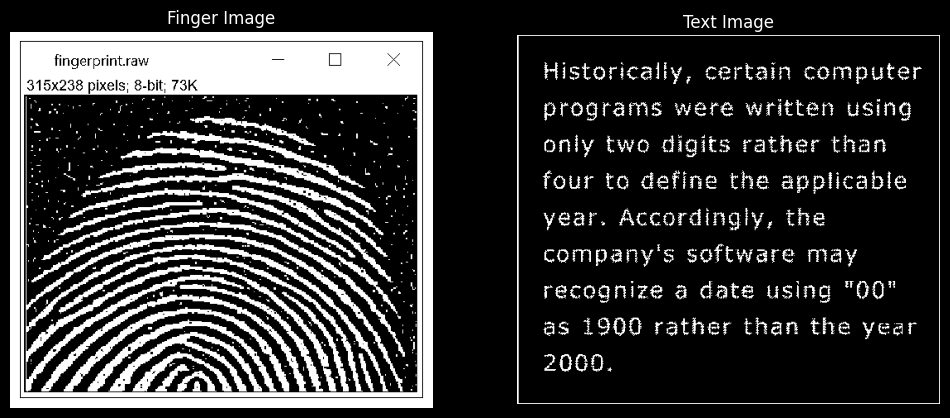

Finger shape: (456, 512)
Text shape: (444, 509)


In [18]:
finger = cv2.imread('finger.png', cv2.IMREAD_GRAYSCALE)
text = cv2.imread('text.png', cv2.IMREAD_GRAYSCALE)

# Binarize images
_, binary_finger = cv2.threshold(finger, 127, 255, cv2.THRESH_BINARY)
_, binary_text = cv2.threshold(text, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(binary_finger, cmap='gray')
plt.title('Finger Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_text, cmap='gray')
plt.title('Text Image')
plt.axis('off')
plt.show()

print(f"Finger shape: {binary_finger.shape}")
print(f"Text shape: {binary_text.shape}")

### 2. Kernels Used

- **Kernel 1**: 3x3 square
- **Kernel 2**: 5x5 square

In [19]:
kernel_3x3 = np.ones((3, 3), dtype=np.uint8)
kernel_5x5 = np.ones((5, 5), dtype=np.uint8)

print("Kernel 1 (3x3):")
print(kernel_3x3)
print("\nKernel 2 (5x5):")
print(kernel_5x5)

Kernel 1 (3x3):
[[1 1 1]
 [1 1 1]
 [1 1 1]]

Kernel 2 (5x5):
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


### 3. Results of Each Morphology Operation

#### 3.1 Finger Image with 3x3 Kernel

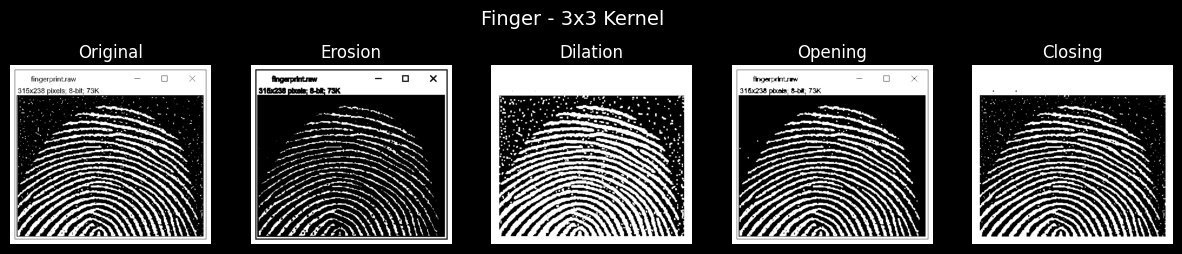

In [20]:
eroded_f = cv2.erode(binary_finger, kernel_3x3, iterations=1)
dilated_f = cv2.dilate(binary_finger, kernel_3x3, iterations=1)
opened_f = cv2.morphologyEx(binary_finger, cv2.MORPH_OPEN, kernel_3x3)
closed_f = cv2.morphologyEx(binary_finger, cv2.MORPH_CLOSE, kernel_3x3)

plt.figure(figsize=(15, 3))
images_f = [binary_finger, eroded_f, dilated_f, opened_f, closed_f]
titles_f = ["Original", "Erosion", "Dilation", "Opening", "Closing"]

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images_f[i], cmap='gray')
    plt.title(titles_f[i])
    plt.axis('off')
plt.suptitle("Finger - 3x3 Kernel", fontsize=14)
plt.show()

#### 3.2 Finger Image with 5x5 Kernel

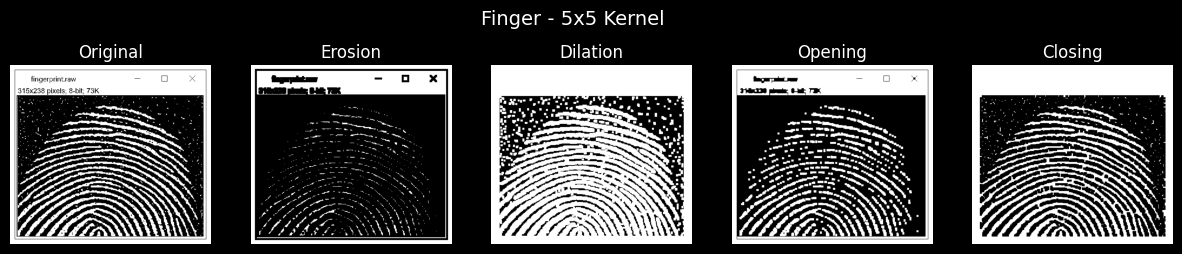

In [21]:
eroded_f5 = cv2.erode(binary_finger, kernel_5x5, iterations=1)
dilated_f5 = cv2.dilate(binary_finger, kernel_5x5, iterations=1)
opened_f5 = cv2.morphologyEx(binary_finger, cv2.MORPH_OPEN, kernel_5x5)
closed_f5 = cv2.morphologyEx(binary_finger, cv2.MORPH_CLOSE, kernel_5x5)

plt.figure(figsize=(15, 3))
images_f5 = [binary_finger, eroded_f5, dilated_f5, opened_f5, closed_f5]

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images_f5[i], cmap='gray')
    plt.title(titles_f[i])
    plt.axis('off')
plt.suptitle("Finger - 5x5 Kernel", fontsize=14)
plt.show()

#### 3.3 Text Image with 3x3 Kernel

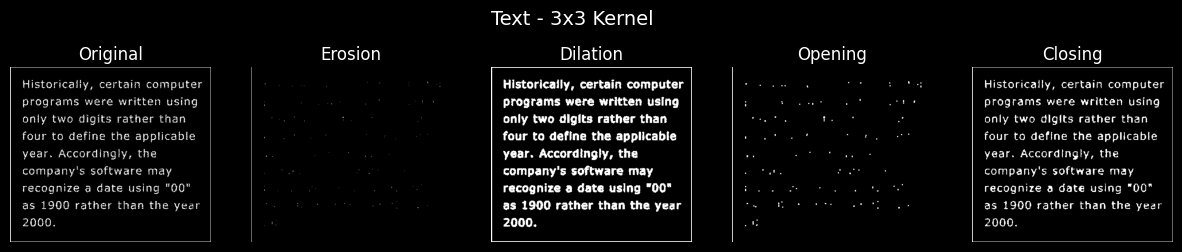

In [22]:
eroded_t = cv2.erode(binary_text, kernel_3x3, iterations=1)
dilated_t = cv2.dilate(binary_text, kernel_3x3, iterations=1)
opened_t = cv2.morphologyEx(binary_text, cv2.MORPH_OPEN, kernel_3x3)
closed_t = cv2.morphologyEx(binary_text, cv2.MORPH_CLOSE, kernel_3x3)

plt.figure(figsize=(15, 3))
images_t = [binary_text, eroded_t, dilated_t, opened_t, closed_t]
titles_t = ["Original", "Erosion", "Dilation", "Opening", "Closing"]

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images_t[i], cmap='gray')
    plt.title(titles_t[i])
    plt.axis('off')
plt.suptitle("Text - 3x3 Kernel", fontsize=14)
plt.show()

#### 3.4 Text Image with 5x5 Kernel

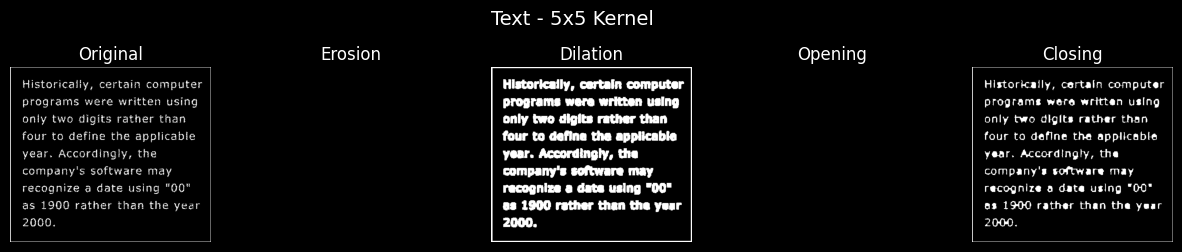

In [23]:
eroded_t5 = cv2.erode(binary_text, kernel_5x5, iterations=1)
dilated_t5 = cv2.dilate(binary_text, kernel_5x5, iterations=1)
opened_t5 = cv2.morphologyEx(binary_text, cv2.MORPH_OPEN, kernel_5x5)
closed_t5 = cv2.morphologyEx(binary_text, cv2.MORPH_CLOSE, kernel_5x5)

plt.figure(figsize=(15, 3))
images_t5 = [binary_text, eroded_t5, dilated_t5, opened_t5, closed_t5]

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images_t5[i], cmap='gray')
    plt.title(titles_t[i])
    plt.axis('off')
plt.suptitle("Text - 5x5 Kernel", fontsize=14)
plt.show()

#### 3.5 Comparison: 3x3 vs 5x5 Kernel

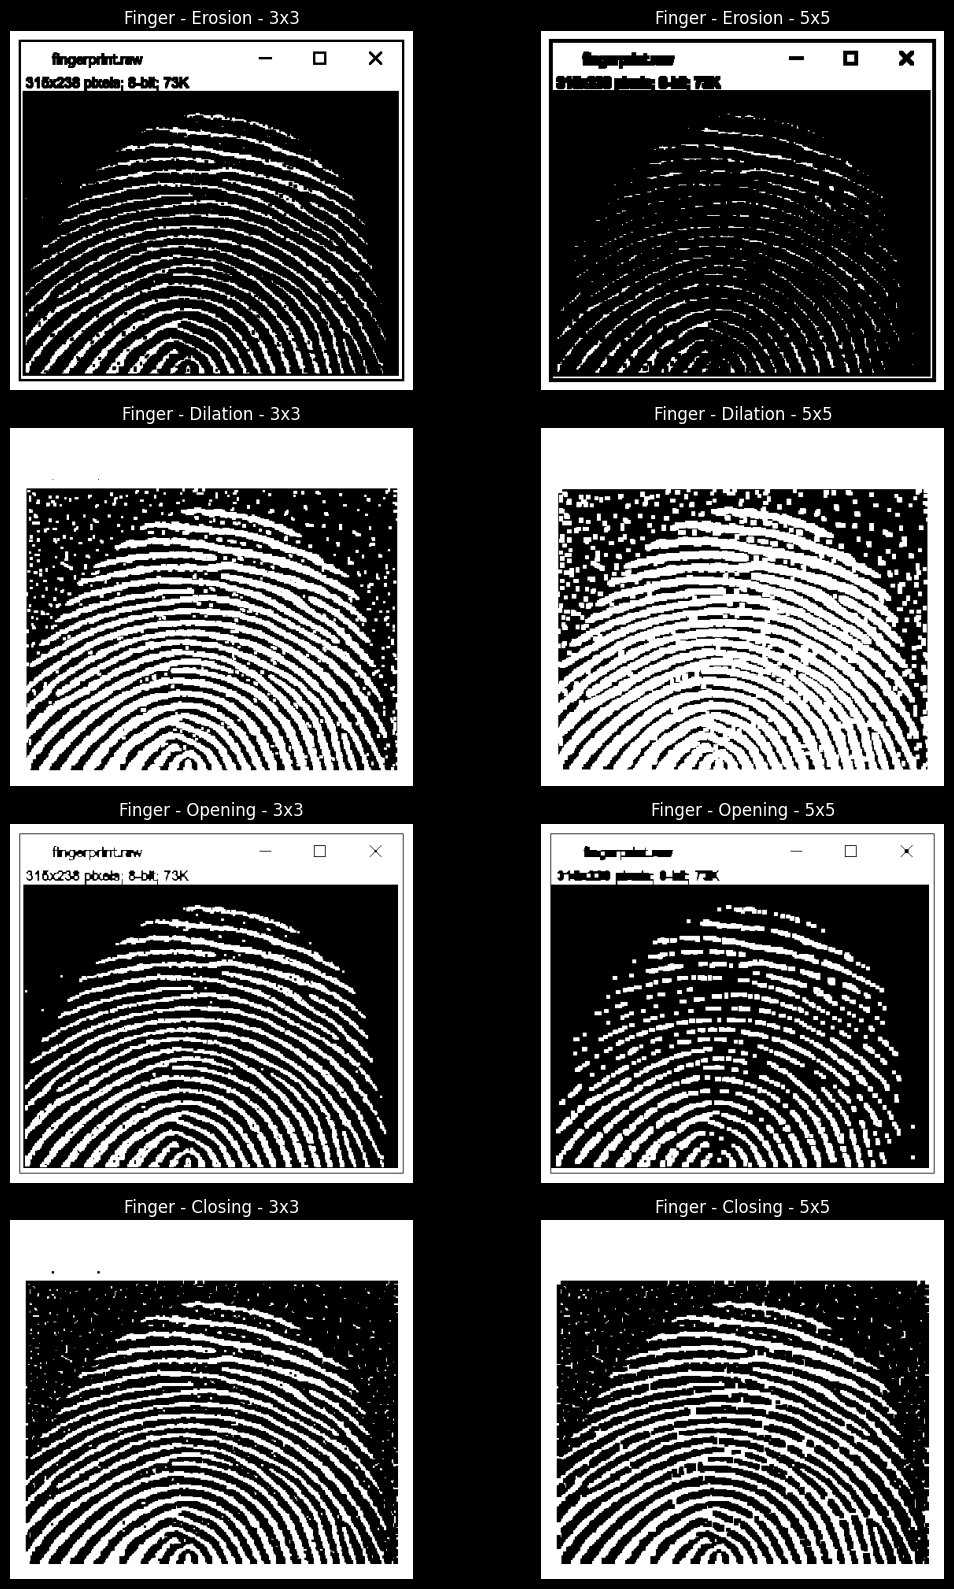

In [24]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

data = [
    (eroded_f, eroded_f5, "Finger - Erosion"),
    (dilated_f, dilated_f5, "Finger - Dilation"),
    (opened_f, opened_f5, "Finger - Opening"),
    (closed_f, closed_f5, "Finger - Closing")
]

for row, (img_3, img_5, title) in enumerate(data):
    axes[row, 0].imshow(img_3, cmap='gray')
    axes[row, 0].set_title(f"{title} - 3x3")
    axes[row, 0].axis('off')
    axes[row, 1].imshow(img_5, cmap='gray')
    axes[row, 1].set_title(f"{title} - 5x5")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

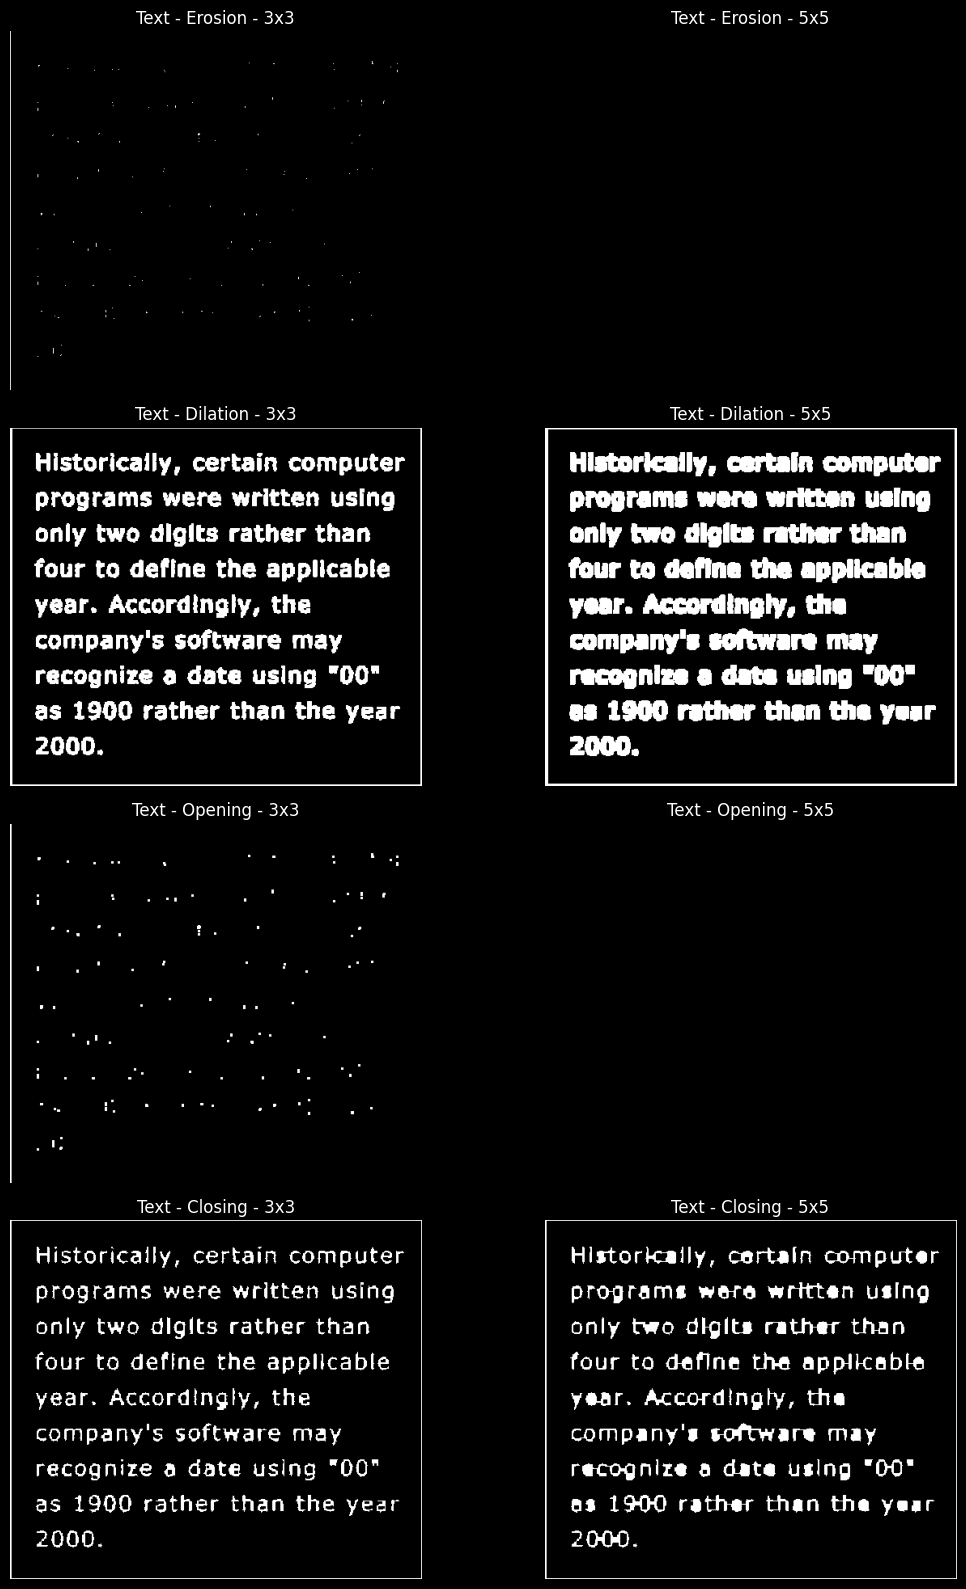

In [25]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

data_t = [
    (eroded_t, eroded_t5, "Text - Erosion"),
    (dilated_t, dilated_t5, "Text - Dilation"),
    (opened_t, opened_t5, "Text - Opening"),
    (closed_t, closed_t5, "Text - Closing")
]

for row, (img_3, img_5, title) in enumerate(data_t):
    axes[row, 0].imshow(img_3, cmap='gray')
    axes[row, 0].set_title(f"{title} - 3x3")
    axes[row, 0].axis('off')
    axes[row, 1].imshow(img_5, cmap='gray')
    axes[row, 1].set_title(f"{title} - 5x5")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

In [26]:
print("Foreground Pixel Count Comparison:")
print("-" * 50)
print(f"{'Operation':<15} {'3x3':<12} {'5x5':<12}")
print("-" * 50)
print(f"{'Finger Original':<15} {np.sum(binary_finger==255):<12} {'-':<12}")
print(f"{'Finger Erosion':<15} {np.sum(eroded_f==255):<12} {np.sum(eroded_f5==255):<12}")
print(f"{'Finger Dilation':<15} {np.sum(dilated_f==255):<12} {np.sum(dilated_f5==255):<12}")
print(f"{'Text Original':<15} {np.sum(binary_text==255):<12} {'-':<12}")
print(f"{'Text Erosion':<15} {np.sum(eroded_t==255):<12} {np.sum(eroded_t5==255):<12}")
print(f"{'Text Dilation':<15} {np.sum(dilated_t==255):<12} {np.sum(dilated_t5==255):<12}")

Foreground Pixel Count Comparison:
--------------------------------------------------
Operation       3x3          5x5         
--------------------------------------------------
Finger Original 107426       -           
Finger Erosion  76329        51648       
Finger Dilation 138738       166624      
Text Original   18210        -           
Text Erosion    649          0           
Text Dilation   40704        59865       


### 4. Conclusion

| Operation | Effect | 3x3 vs 5x5 |
|-----------|--------|-------------|
| **Erosion** | Shrinks white regions, removes small noise | 5x5 removes more |
| **Dilation** | Expands white regions, fills holes | 5x5 expands more |
| **Opening** | Removes small white noise | 5x5 smoother result |
| **Closing** | Fills small black holes/gaps | 5x5 fills more |

**Observations:**

1. **Kernel size matters**: Larger kernels produce stronger effects.
2. **Erosion** removes fine details (finger ridges thin out).
3. **Dilation** thickens features (text characters become bolder).
4. **Opening** removes isolated white noise.
5. **Closing** fills small gaps in the foreground.